
# Benchmark Dashboard

This notebook visualizes performance benchmarks across different formats and modes.

**Metrics:**
- Wall Time (seconds)
- CPU Time (seconds)

Use the plots below to compare performance.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('results/read_benchmark.csv')
df.head()


,mode,format,query_type,wall_time_sec,cpu_time_sec
0,direct,jsonl,read,6.687885,16.828125
1,direct,jsonl,filter,6.974574,22.843750
2,direct,jsonl,groupby,7.347026,26.359375
3,direct,jsonl,window,8.747424,47.140625
4,materialized,jsonl,materialize,16.209844,89.578125


In [8]:

df.groupby(['format','mode','query_type']).mean(numeric_only=True)


wall_time_sec  cpu_time_sec
format  mode         query_type                              
csv     direct       filter            4.154424     25.078125
                     groupby           4.317752     28.687500
                     read              6.655919     23.093750
                     window            6.045288     44.187500
        materialized filter            0.095602      0.718750
                     groupby           0.732995      2.984375
                     materialize      23.793020    105.671875
                     read              0.010317      0.000000
                     window            1.094440      6.312500
jsonl   direct       filter            6.974574     22.843750
                     groupby           7.347026     26.359375
                     read              6.687885     16.828125
                     window            8.747424     47.140625
        materialized filter            0.397855      1.859375
                     groupby           0.734383      3.312500
                     materialize      16.209844     89.578125
                     read              0.059263      0.031250
                     window            2.026537      8.046875
orc     direct       filter            0.272067      1.531250
                     groupby           0.362050      2.578125
                     read              0.139720      0.468750
                     window            1.372972     11.828125
        materialized filter            1.234607      2.468750
                     groupby           0.779458      3.125000
                     materialize      54.335589     79.562500
                     read              0.080940      0.140625
                     window            3.525769     10.703125
parquet direct       filter            0.298435      1.140625
                     groupby           0.291924      1.484375
                     read              0.018338      0.015625
                     window            2.928020     16.187500
        materialized filter            0.142803      0.781250
                     groupby           0.834097      3.031250
                     materialize      22.019459     79.187500
                     read              0.008074      0.078125
                     window            1.714708      6.703125
sqlite  direct       filter            6.958210     32.031250
                     groupby           7.930851     34.468750
                     read             17.644628     23.296875
                     window            8.841741     51.109375
        materialized filter            0.118448      0.781250
                     groupby           0.815077      3.109375
                     materialize     104.660417     98.046875
                     read              0.008862      0.000000
                     window            1.781737      6.703125

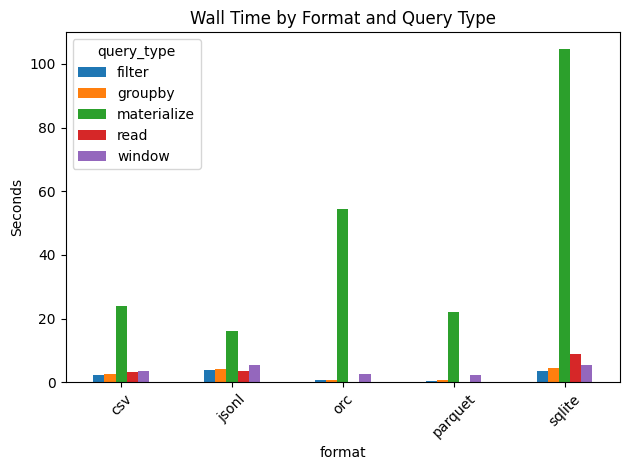

In [9]:
pivot = df.pivot_table(index='format', columns='query_type', values='wall_time_sec', aggfunc='mean')

pivot.plot(kind='bar')
plt.title('Wall Time by Format and Query Type')
plt.ylabel('Seconds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


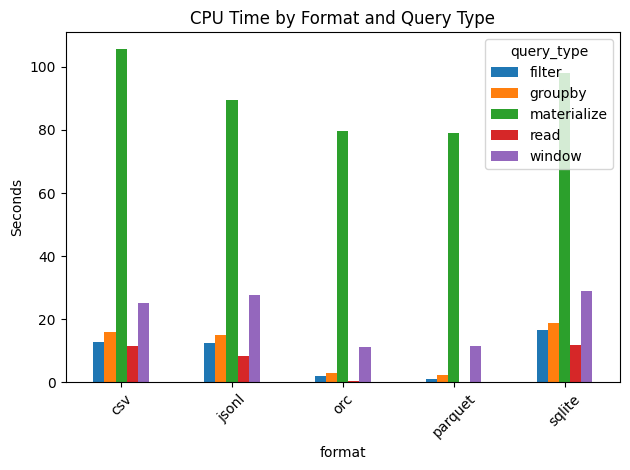

In [10]:

pivot_cpu = df.pivot_table(index='format', columns='query_type', values='cpu_time_sec', aggfunc='mean')

pivot_cpu.plot(kind='bar')
plt.title('CPU Time by Format and Query Type')
plt.ylabel('Seconds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


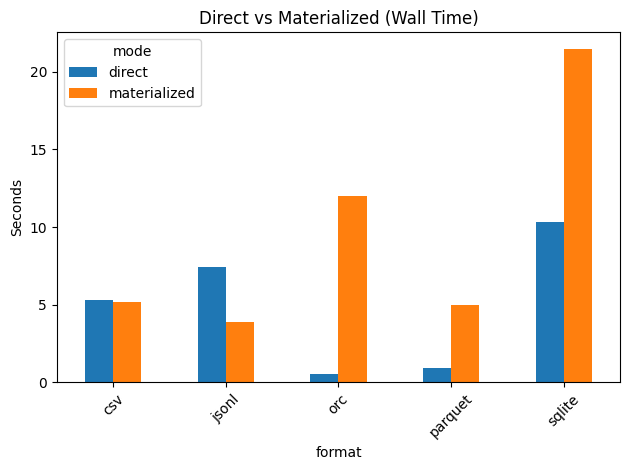

In [11]:

pivot_mode = df.pivot_table(index='format', columns='mode', values='wall_time_sec', aggfunc='mean')

pivot_mode.plot(kind='bar')
plt.title('Direct vs Materialized (Wall Time)')
plt.ylabel('Seconds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
